## Figure S11
For each COM event, find 
(1) if duration in the remote arms 
are predictive of subsequent choice.

Logistic regression.
Because this analysis is in the supplementary, the table entry involved in ```ChangeofMindRemoteTheta()``` is not in the exported database. 

In [1]:
### For each remote arm representation, calculate the cos(animal_head, arm)

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
from scipy import stats
from scipy import linalg
import os
import pickle
import matplotlib.pyplot as plt

In [3]:
from spyglass.shijiegu.changeOfMind_figures.figure4d import find_choice_animal, trial_to_features_supp
from spyglass.shijiegu.Analysis_SGU import ChangeofMind, ChangeofMindRemoteTheta, ChangeofMindRemoteThetaTime

/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-optogenetics': 
 ndx-optogenetics defines ExcitationSource.model as a link to ExcitationSourceModel while the core schema defines it as a link to DeviceModel. ExcitationSourceModel is not a subtype of DeviceModel. 
ndx-optogenetics defines OpticalFiber.model as a link to OpticalFiberModel while the core schema defines it as a link to DeviceModel. OpticalFiberModel is not a subtype of DeviceModel.  
This may cause compatibility issues. Please update the extension version if possible or install an older version of the core schema that is compatible.
  self._check_namespace_conflicts(extension_ns_name=ns_name,
/home/shijiegu/anaconda3/envs/spyglass/lib/python3.10/site-packages/hdmf/spec/namespace.py:484: UserWarning: Schema conflict(s) detected in namespace 'ndx-franklab-novela': 
 ndx-franklab-novela defines CameraDevice.model as an at

In [4]:
from spyglass.shijiegu.changeOfMind import nodes, color_by_rat
from spyglass.shijiegu.decodeHelpers import session2position_name
from spyglass.shijiegu.changeOfMind_remote import do_GLM_subprocess
from spyglass.shijiegu.changeOfMind_remote_interval import parse_remote_master, save_remote_animal, load_remote_animal

### First, we will reparse remote intervals. 
### Instead of having 20ms hard threshold, we will tally the total time each remote arm contains the MAP.

In [5]:
list_of_days_animals = {}
success_animal = {}

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']

animal = 'lewis'
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']

In [ ]:
params = {"use_1d": True,
          "use_home": False,
          "use_center": False,
          "use_outer": True,
          "proportion":0.1,
          "parameter_name": "params_both_max_run_time_2_state"}#"params_both_max_run_time_2_state"} #"params_both_max_all_maze_2_state", "params_both_max_run_time_2_state"

success_animal = {}
for animal in ["molly","lewis","eliot","klein","julio"]:#list_of_days_animals.keys():
    days = list_of_days_animals[animal]
    success = parse_remote_master(animal,
                      days,
                      params,
                      minimum_duration = 0.02,# Not used
                      min_sum_posterior = 0,
                      fill_spyglass = True)

    success_animal[animal] = success

[2026-05-22 11:29:20,483][WARNING]: Skipped checksum for file with hash: 0fa1e19e-726c-b638-1085-377c7e2823b4, and path: /stelmo/nwb/analysis/molly20220416/molly20220416_RLS96PKWQ9.nwb


molly20220416_.nwb
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 2, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 4, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 6, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     pandas    
+------------+ +-------+ +------------+ +------------+ +-----------+ +--------+
molly20220416_ 8         0.1                                         =BLOB=    
 (Total: 1)

Found remote theta in trial  [63]
No triggered decode found for  {'nwb_file_name': 'molly20220416_.nwb', 'epoch': 10, 'proportion': 0.1, 'parameter': 'params_both_max_run_time_2_state'}
molly20220417_.nwb


[2026-05-22 11:29:22,585][WARNING]: Skipped checksum for file with hash: fe93f60f-4849-213c-f0a0-80612ee00f19, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_U2PAI7SDPA.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     pandas    
+------------+ +-------+ +------------+ +------------+ +-----------+ +--------+
molly20220417_ 2         0.1                                         =BLOB=    
 (Total: 1)

Found remote theta in trial  [15]


[2026-05-22 11:29:24,893][WARNING]: Skipped checksum for file with hash: 00b565fd-35e0-5e80-036f-39602240f0cf, and path: /stelmo/nwb/analysis/molly20220417/molly20220417_BZK7V72DS4.nwb


...

Found remote theta in trial  [48]
Found remote theta in trial  [53]
Found remote theta in trial  [53]
Found remote theta in trial  [71]
*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     pandas    
+------------+ +-------+ +------------+ +------------+ +-----------+ +--------+
molly20220418_ 8         0.1                                         =BLOB=    
 (Total: 1)

Found remote theta in trial  [9]
Found remote theta in trial  [9]
Found remote theta in trial  [11]
Found remote theta in trial  [14]
Found remote theta in trial  [17]
Found remote theta in trial  [21]
Found remote theta in trial  [21]
Found remote theta in trial  [32]
Found remote theta in trial  [32]
Found remote theta in trial  [53]
Found remote theta in trial  [54]
Found remote theta in trial  [65]


[2026-05-22 11:29:43,002][WARNING]: Skipped checksum for file with hash: 6082b774-ba96-1106-af39-9ec0f7c66617, and path: /stelmo/nwb/analysis/molly20220418/molly20220418_UL3P3MS7UG.nwb


*nwb_file_name *epoch    *proportion    analysis_file_ pandas_id     pandas    
+------------+ +-------+ +------------+ +------------+ +-----------+ +--------+
molly20220418_ 10        0.1                                         =BLOB=    
 (Total: 1)

Found remote theta in trial  [13]
Found remote theta in trial  [17]
Found remote theta in trial  [17]
Found remote theta in trial  [18]
Found remote theta in trial  [22]
Found remote theta in trial  [22]
Found remote theta in trial  [28]
Found remote theta in trial  [34]
Found remote theta in trial  [34]
Found remote theta in trial  [39]
Found remote theta in trial  [42]
Found remote theta in trial  [49]
Found remote theta in trial  [68]


[2026-05-22 11:29:46,089][WARNING]: Skipped checksum for file with hash: da07703a-5530-a8b6-763a-cafb2149e247, and path: /stelmo/nwb/analysis/molly20220419/molly20220419_SVEGPKV2YW.nwb


Found remote theta in trial  [68]
molly20220419_.nwb


In [221]:
success_animal

{'molly': 1, 'lewis': 1, 'eliot': 1, 'klein': 1, 'julio': 1}

In [6]:
def return_save_name(animal, parameter_name, d1, d2, minimum_duration, min_posterior, proportion = 0.1, use_1d = 1):
    save_name = f'{animal.lower()}_{parameter_name}_{d1}_{d2}_t{minimum_duration}_minp{min_posterior}_p{proportion}_use1d{use_1d}_remoteGLM'
    return save_name

In [7]:
def make_result_df(model_fit, feature_names = ["constant", "previous", "previously_rewarded", "future", "future_correct"]):
    conf_int = model_fit.conf_int(alpha=0.05) # 95% confidence interval
    coefs = model_fit.params
    
    # Create a DataFrame for easier plotting (optional but good practice)
    results_df = pd.DataFrame({
            'coef': coefs,
            'lower_ci': conf_int[:, 0],
            'upper_ci': conf_int[:, 1]
        }, index=feature_names) # Adjust index names as per your model

    return results_df

In [8]:
list_of_days_animals = {}
seq_animals = {}
success_animal = {}

# encoding_set = 'all_maze'
# classifier_param_name = 'default_decoding_gpu_4armMaze'

animal = "molly"
list_of_days_animals[animal]  = ['20220416','20220417','20220418','20220419','20220420']
seq_animals[animal] = 'seq2'

animal = "lewis"
list_of_days_animals[animal] = ['20240105','20240106','20240107','20240108','20240109',
                 '20240110']
seq_animals[animal] = 'rev2'

animal = "eliot"
list_of_days_animals[animal] = ['20221018','20221019','20221020','20221021','20221022','20221023','20221024','20221025','20221026']
seq_animals[animal] = 'seq2'

animal = 'julio'
list_of_days_animals[animal] = ['20230731','20230801','20230802','20230803','20230804',
                 '20230805','20230806','20230807','20230808','20230809','20230810','20230811']
seq_animals[animal] = 'seq2'

animal = 'klein'
list_of_days_animals[animal]  = ['20231101','20231102','20231103','20231104','20231105',
                 '20231106','20231107','20231108']#'20231111']
seq_animals[animal] = 'rev2'

In [9]:
proportion = 0.1
use_1d = 1
parameter_name = "params_both_max_run_time_2_state"
minimum_duration = 0.02 # Not used
min_posterior = 0

### (2) For each animal, tally remote features and then do GLM

In [ ]:
success = {}
for animal in ["molly","eliot", "julio", "lewis", "klein"]:
    tally_dict_ = find_choice_animal(animal, list_of_days_animals[animal],
            parameter_name, minimum_duration = minimum_duration,
            min_posterior = min_posterior,  
            proportion = proportion)
    features_all, response_all, tally_dict, home_visit_all, home_replay_all, home_trial_info_all = trial_to_features_supp(
        tally_dict_, seq_animals[animal],
        minimum_duration = minimum_duration, proportion = 0.1)
    # the 4 features are: "previous", "previously_rewarded", "future", "future_correct"
    
    data = {}
    data["features_all"] = features_all
    data["response_all"] = response_all
    data["tally_dict"] = tally_dict
    data["home_visit_all"] = home_visit_all
    data["home_replay_all"]= home_replay_all
    data["home_trial_info_all"] = home_trial_info_all
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4_supp/'
    save_name = return_save_name(animal, parameter_name,
                                list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                 minimum_duration = minimum_duration, min_posterior = min_posterior, proportion = 0.1, use_1d = 1)
    
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'wb') as file:
        print("data saved to " + file_path)
        pickle.dump(data, file, protocol=pickle.HIGHEST_PROTOCOL)
    success[animal] = 1

In [220]:
success

{'molly': 1, 'eliot': 1, 'julio': 1, 'lewis': 1, 'klein': 1}

### simple conditioning plot

In [10]:
parameter_name = "params_both_max_run_time_2_state" 
minimum_duration = 0.02
min_posterior = 0
#parameter_name = "params_both_max_all_maze_2_state" 

In [11]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
color_by_rat = {"eliot": "C0","molly":"C2","lewis":"C4","julio":"C1","klein":"deepskyblue"}

def sd_err(arr):
    return np.std(arr)/np.sqrt(len(arr))

def plot_one_axis(data1, data2, animal_ind, ax, animal, draw_annotation = False, draw_text = True):
    std = [sd_err(data1), sd_err(data2)]
    mean = [np.mean(data1), np.mean(data2)]
    ax.bar([0 + animal_ind,
                0.3 + animal_ind],mean, yerr=std, width=0.25, hatch=['', '////'],
           color = color_by_rat[animal], alpha=0.6)
    if draw_text:
        ax.text(animal_ind - 0.15, mean[0]+std[0] + 0.1, len(data1), fontsize = 6)
        ax.text(animal_ind + 0.3 - 0.15, mean[1]+std[1] + 0.1, len(data2), fontsize = 6)
        
    # table = np.array([[np.sum(data1 == 0), np.sum(data1 == 1)],[np.sum(data2 == 0), np.sum(data2 == 1)]])
    # res = fisher_exact(table)
    res = ranksums(data1, data2)
    p_value = res.pvalue
    if p_value < 0.05 and draw_annotation:
        starbars.draw_annotation([(animal_ind, animal_ind + 0.3, np.round(p_value, 4))], ax = ax)
    return ax, p_value

def draw_annotation(ijps,ax,height = 0.9):
    for ijp in ijps:
        x1, x2, p = ijp
        if p <= 0.001:
            label = "***"
        elif p <= 0.01:
            label = "**"
        elif p <= 0.05:
            label = "*"
        ax.text(np.mean([x1,x2]), height, label)
    

In [12]:
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars

In [13]:
def return_probabilities(X,Y):
    chosen = Y[X[:,2] == 1] #chosen
    unchosen = Y[X[:,2] == 0] #unchosen
    previous = Y[X[:,0] == 1] #previous
    previous_reward = Y[X[:,1] == 1] #previously_rewarded
    future_correct = Y[X[:,3] == 1] #future correct
    
    same_side = np.sum(Y[X[:,4] == 1]) / len(Y[X[:,4] == 1]) #future correct
    switch_side = np.sum(Y[X[:,5] == 1]) / len(Y[X[:,5] == 1]) #future correct
    return chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side

def return_arr(X, Y):
    chosen = Y[X[:,2] == 1]  #chosen
    unchosen = Y[X[:,2] == 0]  #unchosen
    previous = Y[X[:,0] == 1] #previous
    previous_reward = Y[X[:,1] == 1] #previously_rewarded
    future_correct = Y[X[:,3] == 1] #future correct
    
    same_side = Y[X[:,4] == 1]  #future correct
    switch_side = Y[X[:,5] == 1]  #future correct
    return chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side

def sd_err_p(p, N):
    return np.sqrt(p * (1-p) / N)

def sd_err(arr):
    N = len(arr)
    return np.std(arr)/np.sqrt(N)

def return_mean(chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side):
    return (np.mean(chosen), np.mean(unchosen), np.mean(previous), np.mean(previous_reward),
            np.mean(future_correct), np.mean(same_side), np.mean(switch_side))

def return_sd(chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side):
    return (sd_err(chosen), sd_err(unchosen), sd_err(previous),
            sd_err(previous_reward), sd_err(future_correct), sd_err(same_side), sd_err(switch_side))

molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0_p0.1_use1d1_remoteGLM
p_value 0.8502139642985351
p_value 0.6988003074260428
p_value 0.1913818797836917
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0_p0.1_use1d1_remoteGLM
p_value 0.6965921918309308
p_value 0.5251586463063054
p_value 0.7042915958303941
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0_p0.1_use1d1_remoteGLM
p_value 0.5242108073313039
p_value 0.6867735657141185
p_value 0.5644705882418402
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0_p0.1_use1d1_remoteGLM
p_value 0.1075743500275262
p_value 0.7642480754446205
p_value 0.9009791785597656
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0_p0.1_use1d1_remoteGLM
p_value 0.11220933525942753
p_value 0.5561674995523478
p_value 0.4273367686255436


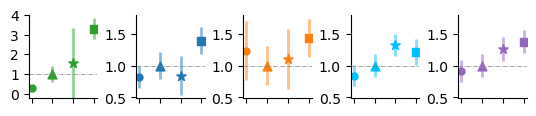

In [299]:
aanimals = ["molly","eliot","julio","klein","lewis"]#["lewis","molly","julio","klein"]

fig, axes = plt.subplots(1,len(animals), figsize=(6, 1.8), sharey = False)

draw_annotation = True

future_all = []
prev_reward_all = []
annotations = []

dt = 0.38
dx= 0.05

ax = axes
animal_ind = 0

for animal in ["molly","eliot","julio","klein","lewis"]:#animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4_supp/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= 0, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]

    (time_chosen, time_unchosen, time_previous, time_previous_reward,
         time_future_correct, time_same_side, time_switch_side) = ([], [], [], [], [], [], [])
    num = []

    for t in range(len(features_all)):
        chosen_bool = features_all[t][:,2] > 0
        previous_bool = features_all[t][:,0] > 0
        previous_reward_bool = features_all[t][:,1] > 0
        future_correct_bool = features_all[t][:,3] > 0
        same_side_bool = features_all[t][:,4] > 0
        switch_side_bool = features_all[t][:,5] > 0

        
        replay_time = features_all[t][:,-1]

        time_chosen.append(replay_time[chosen_bool])
        time_unchosen.append(replay_time[~chosen_bool])
        time_previous.append(replay_time[previous_bool])
        time_previous_reward.append(replay_time[previous_reward_bool])
        time_future_correct.append(replay_time[future_correct_bool])
        time_same_side.append(replay_time[same_side_bool])
        time_switch_side.append(replay_time[switch_side_bool])


    chosen = np.concatenate(time_chosen).ravel() * 1000
    unchosen = np.concatenate(time_unchosen).ravel() * 1000
    previous = np.concatenate(time_previous).ravel() * 1000
    previous_reward = np.concatenate(time_previous_reward).ravel() * 1000
    future_correct = np.concatenate(time_future_correct).ravel() * 1000
    same_side = np.concatenate(time_same_side).ravel() * 1000
    switch_side = np.concatenate(time_switch_side).ravel() * 1000

    chosen_m, unchosen_m, previous_m, previous_reward_m, future_correct_m, same_side_m, switch_side_m = return_mean(
        chosen, unchosen, previous, previous_reward, future_correct, same_side, switch_side)
    chosen_yerr, unchosen_yerr, previous_yerr, previous_reward_yerr, future_correct_yerr, same_side_yerr, switch_side_yerr = return_sd(
        chosen/ previous_m, unchosen/ previous_m, previous/ previous_m, previous_reward/ previous_m, future_correct/ previous_m, same_side/ previous_m, switch_side / previous_m)

    subject = str(animal[0]).upper()
    axes[animal_ind].scatter(np.array([0]) * dt,
               np.array([previous_reward_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = ".", s = 100,)
    axes[animal_ind].scatter(np.array([1]) * dt,
               np.array([previous_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "^", s = 40,)
    axes[animal_ind].scatter(np.array([2]) * dt,
               np.array([future_correct_m]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "*", s = 50,)
    axes[animal_ind].scatter(np.array([3]) * dt,
               np.array([chosen_m, ]) / previous_m,
               color = color_by_rat[animal], label = 'Rat '+ subject,
               marker = "s", s = 40,)
    
    #time_unchosen = np.concatenate(time_unchosen).ravel() * 1000
    #time_unchosen = time_unchosen[~np.isnan(time_unchosen)] #current arm entry is nan'ed out

    num_all[animal] = num

    res = ranksums(previous, chosen)
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05:
        annotations.append((1* dt, 3* dt, np.round(p_value, 4)))

    if draw_annotation:
        starbars.draw_annotation(annotations, ax = axes[animal_ind])

    res = ranksums(previous, future_correct)
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05:
        annotations.append((1* dt, 2* dt, np.round(p_value, 4)))

    if draw_annotation:
        starbars.draw_annotation(annotations, ax = axes[animal_ind])

    res = ranksums(previous, previous_reward)
    p_value = res.pvalue
    print("p_value", p_value)
    if p_value < 0.05:
        annotations.append((1* dt, 0* dt, np.round(p_value, 4)))

    if draw_annotation:
        starbars.draw_annotation(annotations, ax = axes[animal_ind])

    
    axes[animal_ind].errorbar(np.array([0,1,2,3]) * dt,
                 np.array([previous_reward_m, previous_m, future_correct_m, chosen_m, ])/ previous_m,
                  [previous_reward_yerr, previous_yerr, chosen_yerr, future_correct_yerr],
                  fmt = 'None',
                 color = color_by_rat[animal], linewidth = 2, elinewidth = 2, alpha = 0.5)
    axes[animal_ind].axhline(1, linestyle = "-.", color = "grey", linewidth = 0.5)


    if animal_ind == 0:
        axes[animal_ind].set_ylim([-0.2, 4])
        axes[animal_ind].set_yticks([0,1,2,3,4])
    else:
        axes[animal_ind].set_ylim([0.5, 1.8])
        axes[animal_ind].set_yticks([0.5,1,1.5])
    
    axes[animal_ind].set_xticks(np.array([0,1,2,3]) * dt)
    axes[animal_ind].set_xticklabels([])
    axes[animal_ind].spines[['right', 'top']].set_visible(False)
    animal_ind += 1


plt.subplots_adjust(hspace=0.3)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_time_future{draw_text}.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

In [51]:
import seaborn as sns
from spyglass.shijiegu.changeOfMind import color_by_rat

### Fold change plot by rat

In [248]:
import numpy.matlib as ml
from scipy.stats import ranksums
from scipy.stats import fisher_exact
import starbars
import statsmodels.api as sm
from spyglass.shijiegu.changeOfMind_figures.extra_correctness import model2numbers

In [249]:
def model2numbers(ols_result):
    coef_names = ols_result.params.keys()
    coef_est = np.array(ols_result.params)
    pvalues = ols_result.pvalues
    CI = ols_result.conf_int(alpha=0.05)
    #yerr = np.vstack((np.array(CI[0]).reshape((1,-1)), np.array(CI[1]).reshape((1,-1)))) # 2 x coefficients

    coef_names_subset_ind = ["Rat" not in name and "const" not in name for name in coef_names]
    coef_names = np.array(coef_names)[coef_names_subset_ind]
    coef_est = coef_est[coef_names_subset_ind]
    pvalues = pvalues[coef_names_subset_ind]
    CI = CI.loc[coef_names]

    return ols_result.params, coef_names, coef_est, pvalues, CI#, yerr

In [305]:
np.random.seed(2026)
feature_names = ["previous", "previously_rewarded", "future", "future_correct", "same side", "switch side"]

animal_ind = 0
animals = ["julio","lewis","eliot","molly","klein"]

GLM_x = []
GLM_y = []
for animal in animals:
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4_supp/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                     minimum_duration = minimum_duration, min_posterior= 0, proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)
    
    features_all, response_all = data["features_all"], data["response_all"]

    # GLM process
    X = np.vstack(features_all).astype("int") #reshape
    Y = np.vstack([np.array(f[:,-1]).reshape((-1,1)) for f in features_all])
    
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))

    print(animal, "n=" + str(len(Y)/4))

    GLM_x.append(X)
    GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)


julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0_p0.1_use1d1_remoteGLM
julio n=168.0
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0_p0.1_use1d1_remoteGLM
lewis n=380.0
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0_p0.1_use1d1_remoteGLM
eliot n=281.0
molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0_p0.1_use1d1_remoteGLM
molly n=136.0
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0_p0.1_use1d1_remoteGLM
klein n=393.0


In [301]:
feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict["rewarded past"] = GLM_x[:,(len(animals)+1)]
feature_dict["immediate past"] = GLM_x[:,len(animals)]
feature_dict["correct future"] = GLM_x[:,(len(animals)+3)]
feature_dict["immediate next"] = GLM_x[:,(len(animals)+2)]

# feature_dict["same side"] = GLM_x[:,(len(animals)+4)]
# feature_dict["switch side"] = GLM_x[:,(len(animals)+5)]

X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y * 1000

"""a) Mixed Linear Effect"""
ols_model = sm.OLS(y,X)
ols_result1 = ols_model.fit()
print("Mixed Linear Effect \n",ols_result1.summary())

Mixed Linear Effect 
                             OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.013
Method:                 Least Squares   F-statistic:                     9.854
Date:                Fri, 22 May 2026   Prob (F-statistic):           1.07e-13
Time:                        17:26:00   Log-Likelihood:                -29645.
No. Observations:                5432   AIC:                         5.931e+04
Df Residuals:                    5423   BIC:                         5.937e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
const              7.0

In [302]:
coef_names = ols_result1.params.keys()
coef_est = np.array(ols_result1.params)
pvalues = ols_result1.pvalues
CI = ols_result1.conf_int(alpha=0.05)

coef_names_subset_ind = ["Rat" not in name and "const" not in name for name in coef_names]
coef_names = np.array(coef_names)[coef_names_subset_ind]
coef_est = coef_est[coef_names_subset_ind]
pvalues = pvalues[coef_names_subset_ind]
CI = CI.loc[coef_names]

print(coef_names)
print(pvalues)
print(coef_est)
print(CI)

['rewarded past' 'immediate past' 'correct future' 'immediate next']
rewarded past     0.851223
immediate past    0.162130
correct future    0.129697
immediate next    0.001418
dtype: float64
[-0.36940357  2.69638181  3.0044531   6.15379755]
                       0         1
rewarded past  -4.230311  3.491504
immediate past -1.084366  6.477130
correct future -0.881940  6.890847
immediate next  2.375019  9.932576


3.3 0.03
Linear the effect of immediate next is 6.153797552058896, with 95% bound: (2.375018988562594, 9.932576115555198)


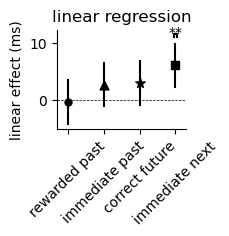

In [304]:
# 4. Create the bar graph using matplotlib

markers = {'rewarded past': ".", "immediate past": "^",
        'immediate next':"s", 'correct future':"*"}
markersizes = {'rewarded past': 100,
               "immediate past": 40,
               'immediate next': 40,
               'correct future': 50}

fig, axes = plt.subplots(1,1,figsize=(3, 3))


#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(ols_result1)
coef_est = coef_est
coef_pd = coef_pd
CI = CI

for (ind,coef_name) in enumerate(coef_names):
    axes.scatter(coef_name, coef_est[ind], color = "k",
                    marker = markers[coef_name], s = markersizes[coef_name])
    axes.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = axes, color = 'k')

axes.set_xticks(np.arange(len(coef_names)))
axes.set_xticklabels(coef_names, rotation=45)
axes.set_title("linear regression")
axes.set_ylabel("linear effect (ms)")
axes.axhline(0,linewidth = 0.5,linestyle='dashed', color = 'k')
#axes.set_ylim([0.5,3])
axes.set_xlim([-0.3,3.3])

next_point_est = coef_pd.loc["immediate next"]
next_CI = CI.loc["immediate next"]
print(f"Linear the effect of immediate next is {next_point_est}, with 95% bound: {next_CI[0],next_CI[1]}")
axes.spines[['right', 'top']].set_visible(False)
fig.tight_layout(pad=3.0, w_pad=0.5, h_pad=1.0) 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_time_GLM_future.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")


molly_params_both_max_run_time_2_state_20220416_20220420_t0.02_minp0_p0.1_use1d1_remoteGLM
eliot_params_both_max_run_time_2_state_20221018_20221026_t0.02_minp0_p0.1_use1d1_remoteGLM
julio_params_both_max_run_time_2_state_20230731_20230811_t0.02_minp0_p0.1_use1d1_remoteGLM
klein_params_both_max_run_time_2_state_20231101_20231108_t0.02_minp0_p0.1_use1d1_remoteGLM
lewis_params_both_max_run_time_2_state_20240105_20240110_t0.02_minp0_p0.1_use1d1_remoteGLM
Optimization terminated successfully.
         Current function value: 0.561208
         Iterations 6
 ===== 
 Mixed Logistics 
                            Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                 5432
Model:                          Logit   Df Residuals:                     5425
Method:                           MLE   Df Model:                            6
Date:                Fri, 22 May 2026   Pseudo R-squ.:                0.002004
Time:                

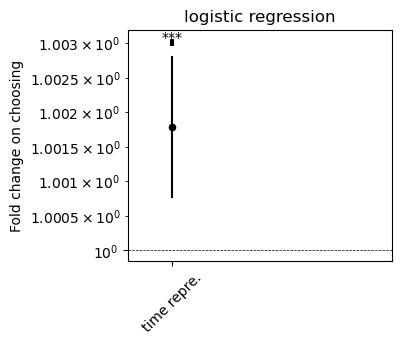

In [272]:
feature_names = ["time repre."] #"correct future"]
fig, ax1 = plt.subplots(1, 1, figsize=(3.4, 3),
                               sharex = True)
GLM_x, GLM_y = [], []
animal_ind = 0 
animals = ["molly", "eliot", "julio", "klein", "lewis"]
for animal in animals:

    """Logistic Regression"""
    output_folder = '/stelmo/shijie/change_of_mind_analysis/figure4_supp/'
    save_name = return_save_name(animal, parameter_name,
                                    list_of_days_animals[animal][0], list_of_days_animals[animal][-1],
                                    minimum_duration = minimum_duration, 
                                    min_posterior = min_posterior,
                                    proportion = 0.1, use_1d = 1)
    print(save_name)
    file_path = output_folder + save_name + '.pkl'
    with open(file_path, 'rb') as file:
        data = pickle.load(file)

    features_all, response_all = data["features_all"], data["response_all"]

    time_chosen = []
    time_unchosen = []
    num = []

    for t in range(len(features_all)):
        chosen_bool = features_all[t][:,2] > 0
        chosen_arm = np.argwhere(chosen_bool)
        
        last_bool = features_all[t][:,-2]
        replay_time = features_all[t][:,-1]

        # print("chosen_bool", chosen_bool)
        # print("replay_time", replay_time)
        # print("\n")

        time_chosen.append(replay_time[chosen_arm])
        time_unchosen.append(replay_time[~chosen_bool])

    time_chosen = np.concatenate(time_chosen).reshape((-1,1)) * 1000
    time_unchosen = np.concatenate(time_unchosen).reshape((-1,1)) * 1000
    time_unchosen = time_unchosen[~np.isnan(time_unchosen)] #current arm entry is nan'ed out
    time_unchosen = time_unchosen.reshape((-1,1))


    # GLM process
    X = np.vstack((time_chosen, time_unchosen)).reshape((-1,1)) #reshape
    animal_category = np.array([a == animal for a in animals]).reshape((1,-1))
    X_animal_category = ml.repmat(animal_category, np.shape(X)[0], 1)
    X = np.hstack((X_animal_category, X))
    
    Y = np.vstack((np.ones_like(time_chosen), np.zeros_like(time_unchosen))).reshape((-1,1)).astype("int") #reshape

    GLM_x.append(X)
    GLM_y.append(Y)
    
GLM_x = np.vstack(GLM_x)
GLM_y = np.vstack(GLM_y)

feature_dict = {f"Rat {animals[animal_ind][0].upper()}":GLM_x[:,animal_ind] for animal_ind in range(len(animals))}
feature_dict[feature_names[0]] = GLM_x[:,len(animals)]


X = pd.DataFrame(feature_dict)
X = sm.add_constant(X)
y = GLM_y


"""Logistic"""
logistic_model = sm.Logit(y, X)
logistic_result1 = logistic_model.fit()

# 3. View the model summary
print(" ===== \n Mixed Logistics \n",logistic_result1.summary())

#### axis 1
coef_pd, coef_names, coef_est, pvalues, CI = model2numbers(logistic_result1)
coef_est = np.exp(coef_est) 
CI = np.exp(CI) 
print("coef_est", coef_est)
print("CI", CI)


for (ind,coef_name) in enumerate(feature_names):
    ax1.scatter(coef_name, coef_est[ind], color = "k",
                    s = 20)
    ax1.plot([coef_name,coef_name],[CI.loc[coef_name][0], CI.loc[coef_name][1]], color = 'k')

for coef_ind in range(len(pvalues)):
    pvalue = pvalues[coef_ind]
    if pvalue < 0.05:
        starbars.draw_annotation([(coef_ind, coef_ind, np.round(pvalue, 4))], ax = ax1, color = 'k')

ax1.set_xticks(np.arange(len(coef_names)))
ax1.set_xticklabels(coef_names, rotation=45)
ax1.set_title("logistic regression")
ax1.set_ylabel("Fold change on choosing")
ax1.axhline(1,linewidth = 0.5,linestyle='dashed', color = 'k')
#ax1.set_ylim([0.5,3])
ax1.set_xlim([-0.1,0.5])
ax1.set_yscale('log') 

file_path = f"/home/shijiegu/Documents/spyglass/notebooks/Change of Mind Analysis/final_figures/figure3/figure3_time_GLM_future.pdf"
fig.savefig(file_path, format="pdf", bbox_inches="tight")

## End here